IT Operations Performance Analysis

Introduction

Using Python, I took a hard look at our system logs to understand why our IT services were dropping. Once I found the bottlenecks, I suggested some key improvements to boost our overall uptime

Objective

- Identify systems with the most incidents  
- Identify systems with the highest downtime  
- Provide insights for IT management decision-making

Data Loading

In [51]:
import pandas as pd
df=pd.read_csv('it_operations_data1.csv')
df.head()

,system_name,incident_type,severity,downtime_minutes,incident_date
0,Email Server,Server Crash,High,120,2024-01-10
1,Email Server,Network Issue,Medium,45,2024-02-12
2,Payrool System,Application Error,High,90,2024-02-15
3,Payrool System,Server Overload,High,80,2024-04-02
4,HR Portal,Login Failure,Low,10,2024-03-01


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   system_name       7 non-null      str  
 1   incident_type     7 non-null      str  
 2   severity          7 non-null      str  
 3   downtime_minutes  7 non-null      int64
 4   incident_date     7 non-null      str  
dtypes: int64(1), str(4)
memory usage: 412.0 bytes


In [36]:
df.describe()

,downtime_minutes
count,7.000000
mean,62.142857
std,37.622815
min,10.000000
25%,37.500000
50%,60.000000
75%,85.000000
max,120.000000


Total incidents per system

In [49]:
df['system_name'].value_counts()

system_name
Email Server      2
Payroll System    2
HR Portal         2
CRM System        1
Name: count, dtype: int64

Total downtime per system

In [48]:
df.groupby("system_name")["downtime_minutes"].sum()

system_name
CRM System         60
Email Server      165
HR Portal          40
Payroll System    170
Name: downtime_minutes, dtype: int64

System with highest downtime

In [47]:
df.groupby("system_name")["downtime_minutes"].sum().idxmax()

'Payroll System'

Visualization

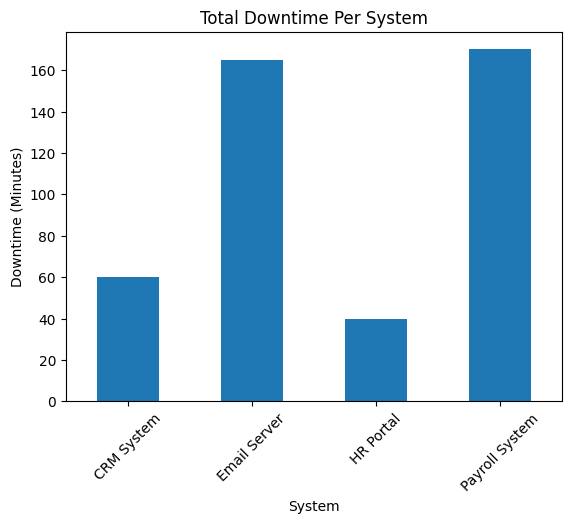

In [46]:
df.groupby("system_name")["downtime_minutes"].sum().plot(kind="bar")
plt.title("Total Downtime Per System")
plt.xlabel("System")
plt.ylabel("Downtime (Minutes)")
plt.xticks(rotation=45)
plt.show()

Key Finding

Payroll System has the highest downtime and requires attention.